# Baseline Result Summary

This notebook reads the baseline `evaluation.txt` file and provides:

1. A summary table of `PSNR / MSE / MAE`.
2. Image overviews for `comparison.png`, `loss_curve.png`, `metric_curves.png`, and `final_reconstruction.png`.


In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

try:
    import pandas as pd
except ImportError:
    pd = None

BASE_DIR = Path.cwd()
IMAGE_NAMES = [
    'comparison.png',
    'loss_curve.png',
    'metric_curves.png',
    'final_reconstruction.png',
]

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.unicode_minus'] = False


In [2]:
def parse_evaluation_txt(path: Path):
    text = path.read_text(encoding='utf-8')

    def extract(metric: str) -> float:
        match = re.search(rf'{metric}:\s*([0-9.]+)', text)
        if match is None:
            raise ValueError(f'Cannot find {metric} in {path}')
        return float(match.group(1))

    return {
        'Experiment': 'Baseline',
        'PSNR': extract('psnr'),
        'MSE': extract('mse'),
        'MAE': extract('mae'),
    }


record = parse_evaluation_txt(BASE_DIR / 'evaluation.txt')
record


{'Experiment': 'Baseline',
 'PSNR': 30.5979,
 'MSE': 0.00087138,
 'MAE': 0.01989225}

In [3]:
if pd is not None:
    summary_df = pd.DataFrame([record])[['Experiment', 'PSNR', 'MSE', 'MAE']]
    display(summary_df.style.format({'PSNR': '{:.4f}', 'MSE': '{:.8f}', 'MAE': '{:.8f}'}))
else:
    print('pandas is not installed. Printing raw record instead:')
    print(record)


,Experiment,PSNR,MSE,MAE
0,Baseline,30.5979,0.00087138,0.01989225


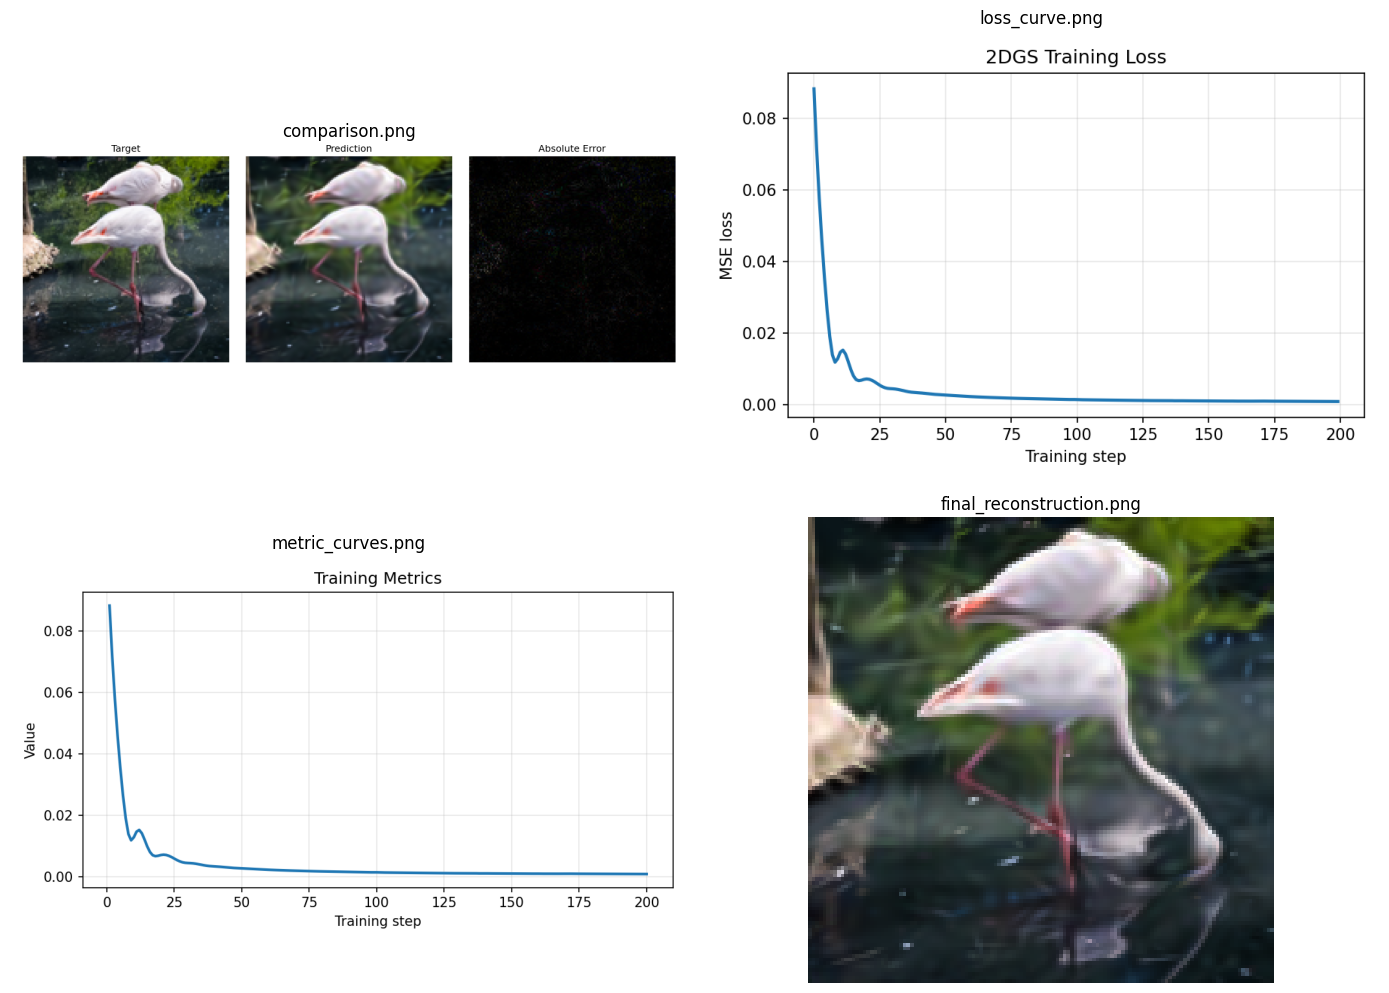

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, image_name in zip(axes, IMAGE_NAMES):
    image_path = BASE_DIR / image_name
    if image_path.exists():
        image = mpimg.imread(image_path)
        ax.imshow(image)
        ax.set_title(image_name, fontsize=12)
    else:
        ax.text(0.5, 0.5, f'Missing\n{image_name}', ha='center', va='center', fontsize=12)
        ax.set_title(image_name, fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()
